## Noise Bliss
###### https://github.com/calanuzao/noise-bliss
Denoising Algorithms for Acoustic Scene Classification in Deep Learning Models with the SONYC-UST Dataset

# Importing Modules

In [1]:
# libraries
import utils as u
import models as m 

# apis
import IPython.display as ipd 
import matplotlib.pyplot as plt
import os
import pandas as pd
import random
import torch
import torchaudio
import tensorflow as tf 

# validating audio data set
import soundata

In [2]:
# tensorflow and tensorflow-metal
print("TensorFlow Version: ", tf.__version__)
print("Is GPU available: ", tf.config.list_physical_devices("GPU"))

TensorFlow Version:  2.19.0
Is GPU available:  [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


# Utilizing Soundata as Data Loader
https://soundata.readthedocs.io/en/latest/

In [5]:
# available datasets in soundata
for dataset in soundata.list_datasets():
    print(dataset)

dcase23_task2
dcase23_task4b
dcase23_task6a
dcase23_task6b
dcase_bioacoustic
dcase_birdVox20k
eigenscape
eigenscape_raw
esc50
freefield1010
fsd50k
fsdnoisy18k
marco
singapura
starss2022
tau2019sse
tau2019uas
tau2020sse_nigens
tau2020uas_mobile
tau2021sse_nigens
tau2022uas_mobile
tut2017se
urbansed
urbansound8k
warblrb10k


# Defining Data Directory and Structure.

In [6]:
data_home = '/Users/calodii/Desktop/stuff/home/dl4m/noise-bliss/data/sonyc-ust'

annotations_path = os.path.join(data_home, 'annotations.csv')
debug_df = pd.read_csv(annotations_path)
print("Columns in annotations.csv:")
print(debug_df.columns.tolist())
print("\nFirst few rows:")
print(debug_df.head())

Columns in annotations.csv:
['split', 'sensor_id', 'audio_filename', 'annotator_id', 'borough', 'block', 'latitude', 'longitude', 'year', 'week', 'day', 'hour', '1-1_small-sounding-engine_presence', '1-2_medium-sounding-engine_presence', '1-3_large-sounding-engine_presence', '1-X_engine-of-uncertain-size_presence', '2-1_rock-drill_presence', '2-2_jackhammer_presence', '2-3_hoe-ram_presence', '2-4_pile-driver_presence', '2-X_other-unknown-impact-machinery_presence', '3-1_non-machinery-impact_presence', '4-1_chainsaw_presence', '4-2_small-medium-rotating-saw_presence', '4-3_large-rotating-saw_presence', '4-X_other-unknown-powered-saw_presence', '5-1_car-horn_presence', '5-2_car-alarm_presence', '5-3_siren_presence', '5-4_reverse-beeper_presence', '5-X_other-unknown-alert-signal_presence', '6-1_stationary-music_presence', '6-2_mobile-music_presence', '6-3_ice-cream-truck_presence', '6-X_music-from-uncertain-source_presence', '7-1_person-or-small-group-talking_presence', '7-2_person-or-sma

In [7]:
try:
    audio_files, labels = u.load_data(data_home)
    print(f"Successfully loaded {len(audio_files)} audio files")
    if len(audio_files) > 0:
        print("\nSample audio file:", audio_files[0])
        print("\nSample label (multi-hot encoded):", labels[0])
        print("\nLabel meanings:")
        for category, idx in u.label_taxonomy.items():
            if labels[0][idx] == 1:
                print(f"- {category}")
except Exception as e:
    print(f"Error loading data: {str(e)}")
    import traceback
    print(traceback.format_exc())

Successfully loaded 18510 audio files

Sample audio file: /Users/calodii/Desktop/stuff/home/dl4m/noise-bliss/data/sonyc-ust/audio/00_026884.wav

Sample label (multi-hot encoded): [1, 1, 1, 0, 0, 0, 0, 0]

Label meanings:
- engine
- machinery-impact
- non-machinery-impact


# Understanding and Plotting Data

Train sensors       : {1, 2, 8, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 45}
Validate sensors    : {0, 3, 4, 5, 6, 7, 9, 10, 46}
Test sensors        : {0, 1, 2, 3, 4, 5, 6, 7, 9, 10, 11, 12, 13, 14, 16, 17, 18, 20, 22, 23, 24, 25, 27, 29, 30, 31, 32, 33, 34, 35, 37, 38, 39, 40, 41, 45, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 61}


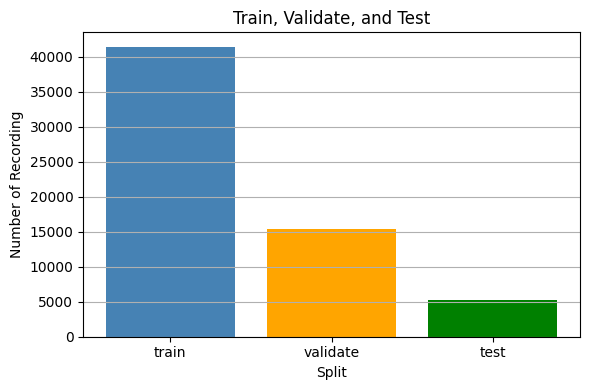

In [10]:
# plotting data
train_df = debug_df[debug_df['split'] == 'train']
valid_df = debug_df[debug_df['split'] == 'validate']
test_df = debug_df[debug_df['split'] == 'test']

# printing sensor sets
print("Train sensors       :", set(train_df['sensor_id']))
print("Validate sensors    :", set(valid_df['sensor_id']))
print("Test sensors        :", set(test_df['sensor_id']))

# counting reading per split
split_counts = debug_df['split'].value_counts().reindex(
    ['train', 'validate', 'test'], fill_value=0
)

# plotting recordings
plt.figure(figsize=(6, 4))
colors = ['steelblue', 'orange', 'green']
plt.bar(split_counts.index, split_counts.values, color=colors[:len(split_counts)])

plt.title('Train, Validate, and Test')
plt.xlabel('Split')
plt.ylabel('Number of Recording')
plt.grid(axis='y')
plt.tight_layout()
plt.legend
plt.show()

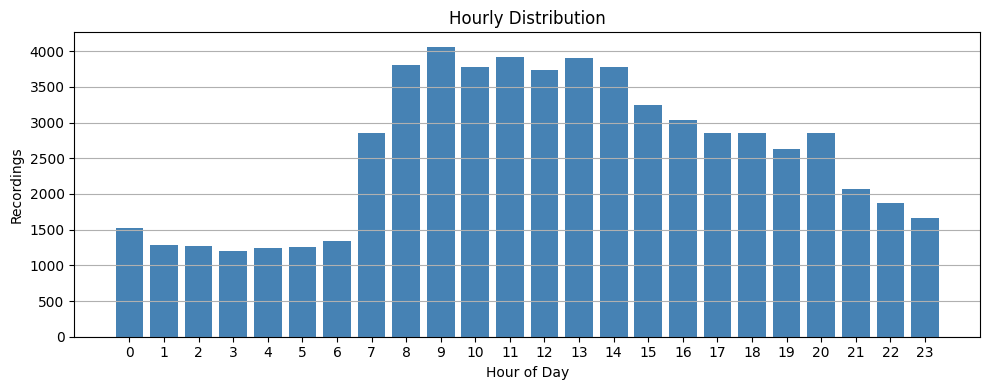

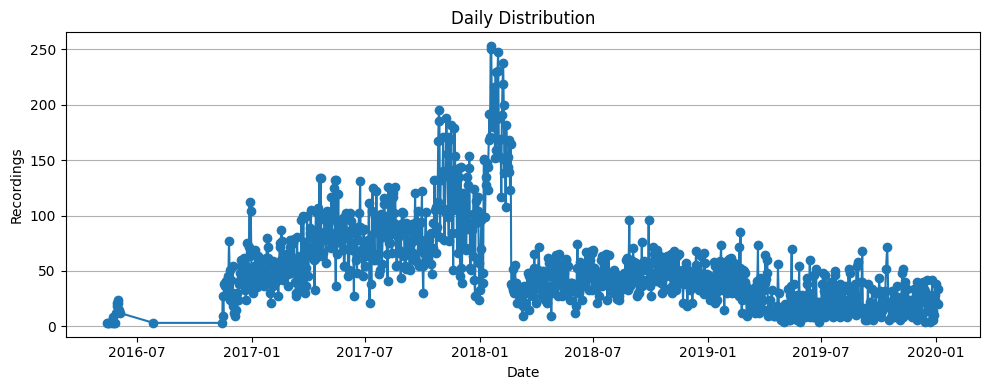

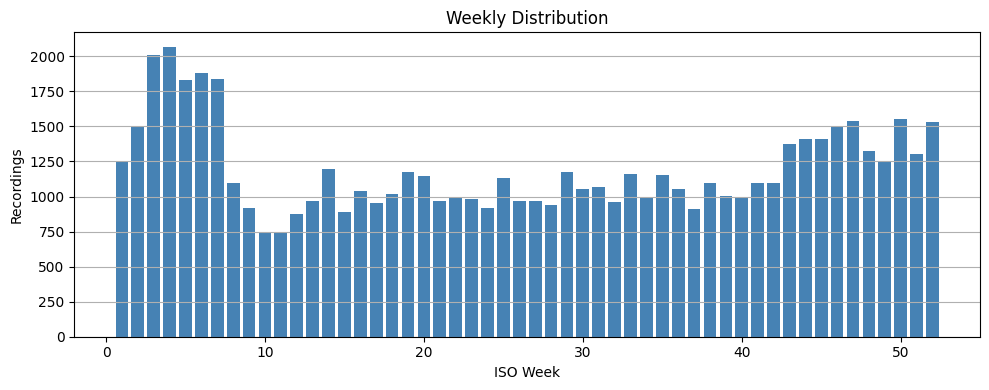

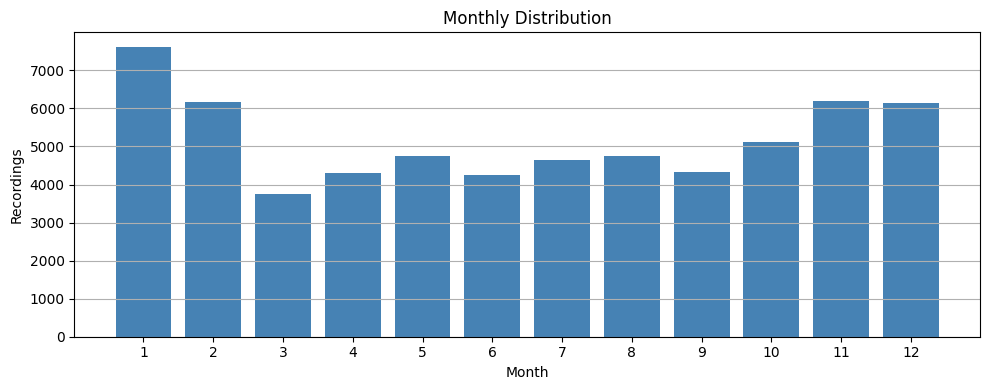

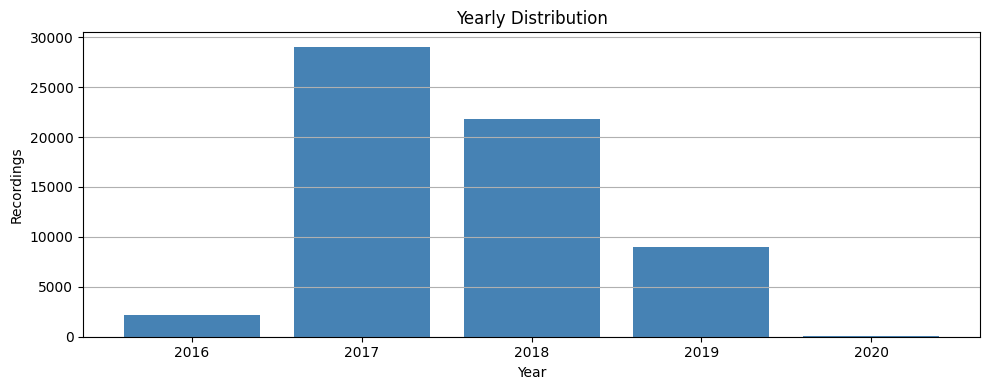

In [11]:
# plotting temporal data 
debug_df = u.construct_datetime(debug_df)
u.compute_and_plot_distributions(debug_df)

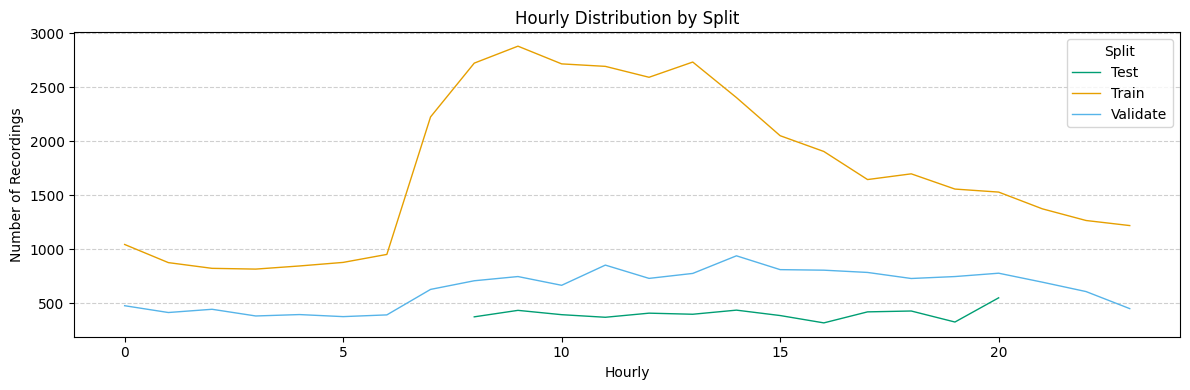

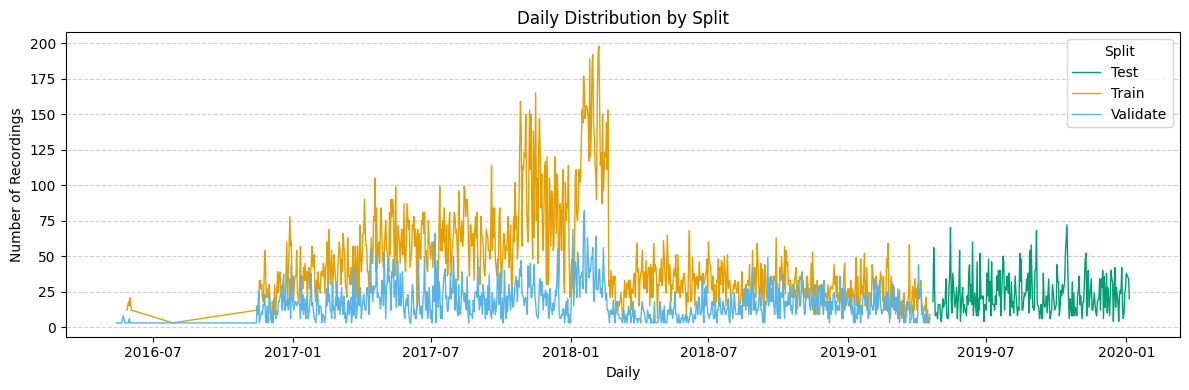

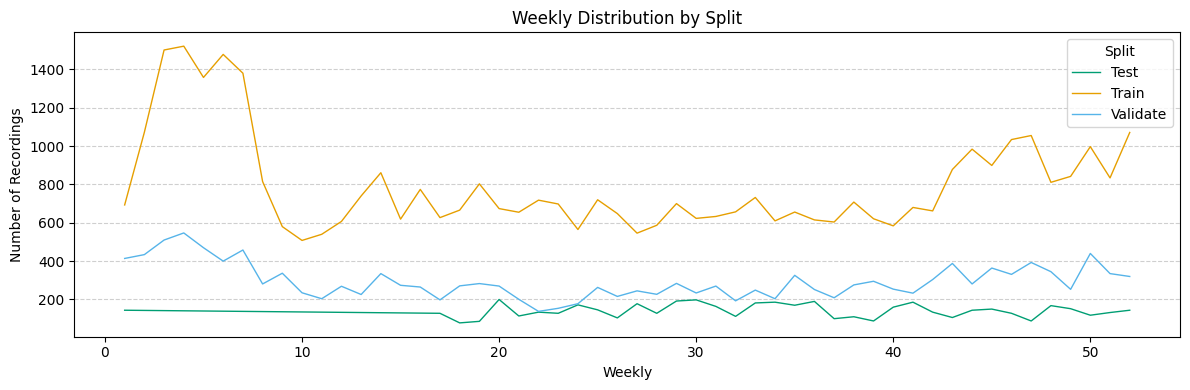

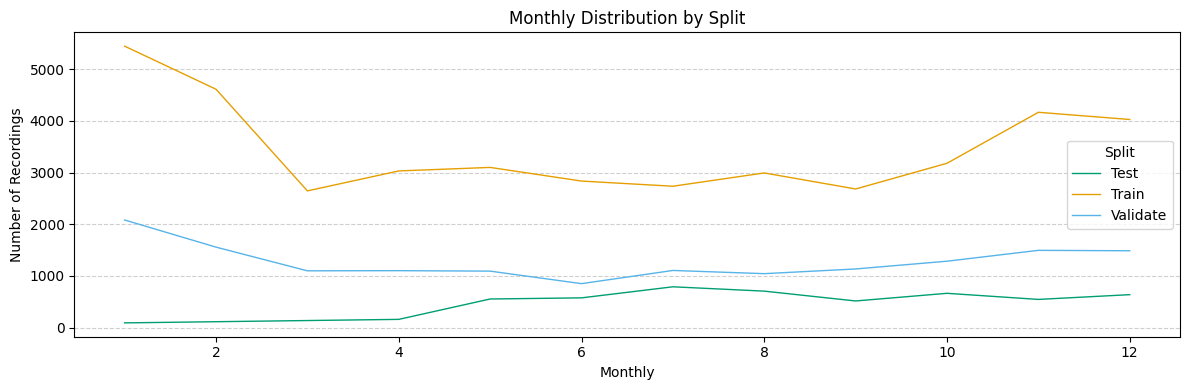

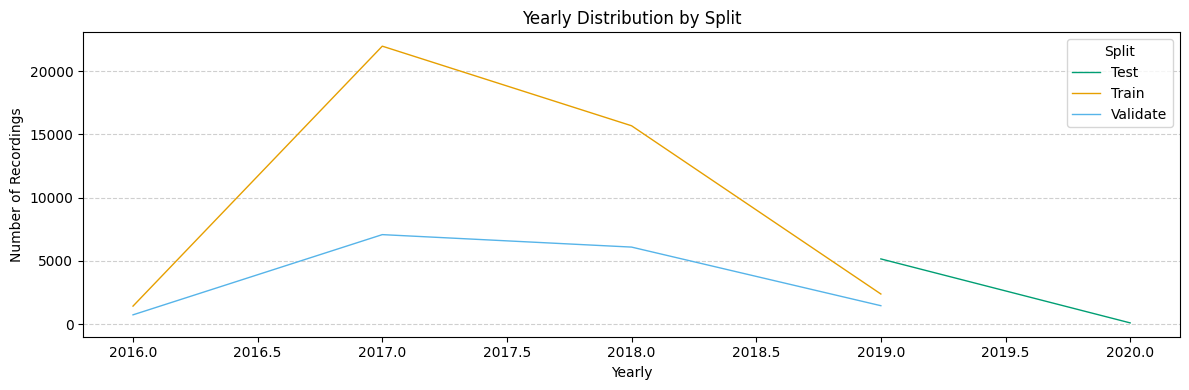

In [12]:
# plotting temporal data by split
u.plot_distributions_by_split(debug_df)

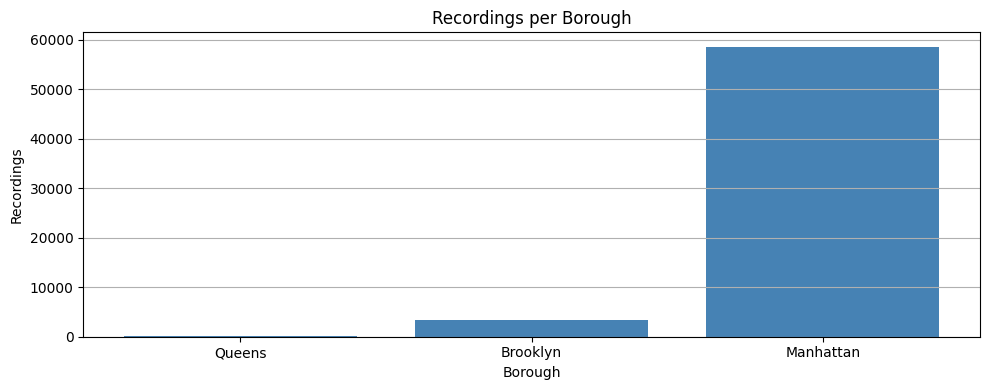

In [13]:
# borough mapping
borough_map = {
    1: "Manhattan",
    2: "Bronx",
    3: "Brooklyn",
    4: "Queens",
    5: "Staten Island"
}

# Map borough ID to name
debug_df['borough_name'] = debug_df['borough'].map(borough_map)

# Count number of recordings per borough (with data)
borough_counts = debug_df['borough_name'].value_counts().sort_index()

# Order from greatest to least
ordered_boroughs = [name for id_, name in borough_map.items() if name in borough_counts.index]
borough_counts = borough_counts[ordered_boroughs]
borough_counts = borough_counts.sort_values(ascending=True)

# ---------- Plot ----------
u.plot_distribution(
    borough_counts,
    xlabel="Borough",
    ylabel="Recordings",
    title="Recordings per Borough"
)

/var/folders/7s/4_xdxsgd3g717br165rj0xy00000gn/T/ipykernel_47884/402717847.py:54: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ordered_sensors.groupby('borough_name')


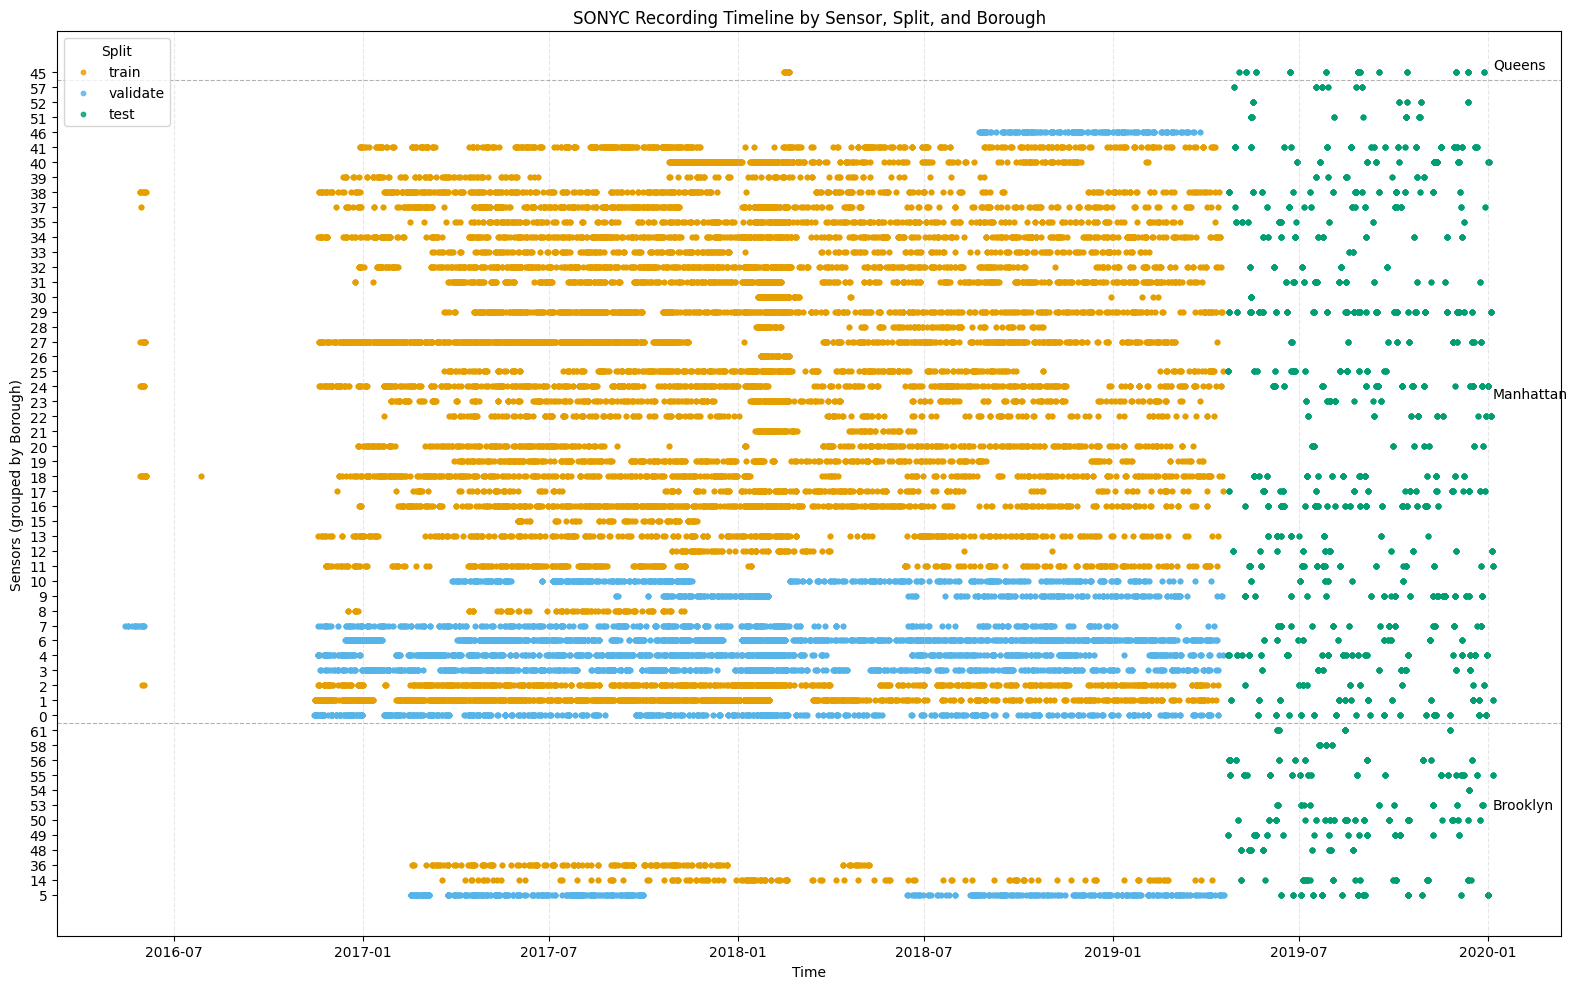

In [14]:
borough_map = {
    1: "Manhattan",
    2: "Bronx",
    3: "Brooklyn",
    4: "Queens",
    5: "Staten Island"
}

debug_df['borough_name'] = debug_df['borough'].map(borough_map)

ordered_sensors = (
    debug_df[['sensor_id', 'borough_name']]
    .drop_duplicates()
    .sort_values(['borough_name', 'sensor_id'])
)

sensor_order = {sid: i for i, sid in enumerate(ordered_sensors['sensor_id'])}
debug_df['sensor_y'] = debug_df['sensor_id'].map(sensor_order)

split_colors = {
    'train': '#E69F00',     # orange
    'validate': '#56B4E9',  # sky blue
    'test': '#009E73'       # teal
}

plt.style.use('default')
fig, ax = plt.subplots(figsize=(16, 10))

for split, color in split_colors.items():
    subset = debug_df[debug_df['split'] == split]
    ax.scatter(
        subset['datetime'],
        subset['sensor_y'],
        s=10,
        color=color,
        alpha=0.8,
        label=split
    )

borough_boundaries = []
current_borough = None

for i, (_, row) in enumerate(ordered_sensors.iterrows()):
    borough = row['borough_name']
    if borough != current_borough:
        if i != 0:
            borough_boundaries.append(i - 0.5)
        current_borough = borough

for y in borough_boundaries:
    ax.axhline(y=y, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)

borough_labels = (
    ordered_sensors.groupby('borough_name')
    .apply(lambda x: sensor_order[x['sensor_id'].iloc[0]] + len(x) / 2)
)

for borough, y in borough_labels.items():
    ax.text(
        debug_df['datetime'].max(),
        y,
        borough,
        va='center',
        ha='left',
        fontsize=10,
        color='black'
    )

ax.set_xlabel("Time")
ax.set_ylabel("Sensors (grouped by Borough)")
ax.set_title("SONYC Recording Timeline by Sensor, Split, and Borough")
ax.set_yticks(list(sensor_order.values()))
ax.set_yticklabels(list(sensor_order.keys()))
ax.grid(True, axis='x', linestyle='--', alpha=0.3)
ax.legend(title="Split", loc='upper left', frameon=True)
plt.tight_layout()
plt.show()

--------------------------------------------------------------------------------

                         PLOT AND PLAYBACK AUDIO FILES                          

--------------------------------------------------------------------------------
Loaded audio file : /Users/calodii/Desktop/stuff/home/dl4m/noise-bliss/data/sonyc-ust/audio/27_018331.wav
Waveform shape    : (1, 480000)
Sample rate       : 48000 Hz
--------------------------------------------------------------------------------


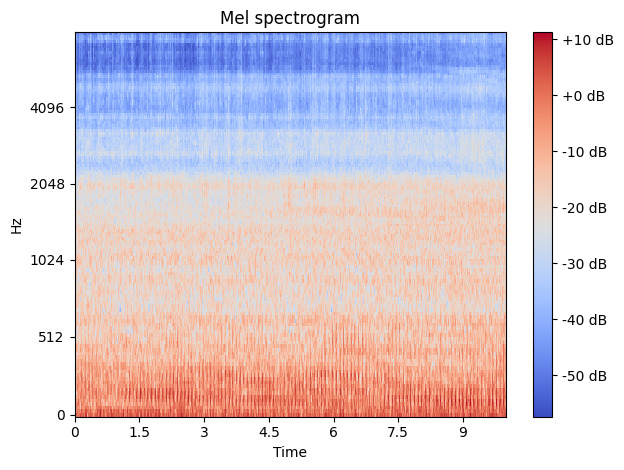

In [15]:
example_audio = random.choice(audio_files)
waveform, sample_rate = torchaudio.load(example_audio)
waveform = waveform.numpy()

print("-" * 80)
title = "PLOT AND PLAYBACK AUDIO FILES"
print("\n" + title.center(80) + "\n")
print("-" * 80)
print(f"Loaded audio file : {example_audio}")
print(f"Waveform shape    : {waveform.shape}")
print(f"Sample rate       : {sample_rate} Hz")
print("-" * 80)

u.mel_spectrogram(
    waveform,
    sample_rate,
    n_mels=128,
    hop_length=512
)

ipd.Audio(example_audio)

# Creating Dataset

In [16]:
# create datasets
target_shape = (128, 128)
batch_size = 32

# defining audio directory
audio_dir = os.path.join(data_home, 'audio')

# filter audio files by split
train_files = [os.path.join(audio_dir, f) for f in debug_df[debug_df['split'] == 'train']['audio_filename'].unique()]
val_files = [os.path.join(audio_dir, f) for f in debug_df[debug_df['split'] == 'validate']['audio_filename'].unique()]
test_files = [os.path.join(audio_dir, f) for f in debug_df[debug_df['split'] == 'test']['audio_filename'].unique()]

# Print some info
print(f"Number of training files: {len(train_files)}")
print(f"Number of validation files: {len(val_files)}")
print(f"Number of test files: {len(test_files)}")

# Create datasets
# Create datasets with annotations
train = u.data_set(train_files, batch_size, target_shape, annotations_df=debug_df)
validation = u.data_set(val_files, batch_size, target_shape, annotations_df=debug_df)
test = u.data_set(test_files, batch_size, target_shape, annotations_df=debug_df, shuffle=False)

Number of training files: 13538
Number of validation files: 4308
Number of test files: 664


#### SONY-UST Dataset Analysis

Sensor Distribution:
- Training: 35 sensors (IDs 1-41, 45)
- Validation: 9 sensors (IDs 0,3-7,9,10,46)
- Test: 48 sensors (mix of existing and new sensors 48-61)

Audio File Details:
- Sample rate: 48kHz
- Duration: 10 seconds (480000 samples)
- Single channel audio (shape: 1, 480000)

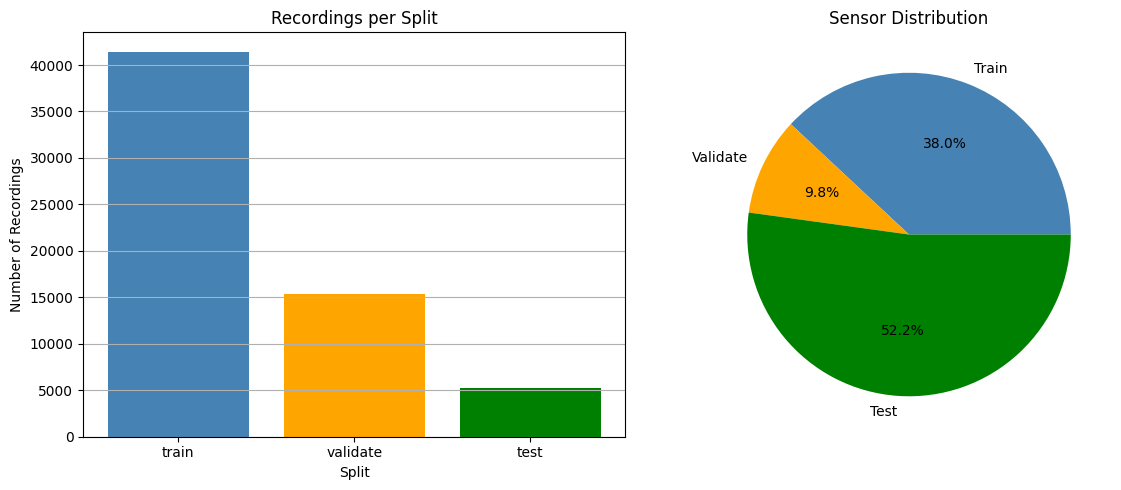

In [17]:
# adding pie chart because my mind likes it better ~ chris lanuza 2025
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
colors = ['steelblue', 'orange', 'green']
plt.bar(split_counts.index, split_counts.values, color=colors[:len(split_counts)])
plt.title('Recordings per Split')
plt.xlabel('Split')
plt.ylabel('Number of Recordings')
plt.grid(axis='y')
plt.subplot(1, 2, 2)
sensor_counts = [len(set(train_df['sensor_id'])), 
                len(set(valid_df['sensor_id'])), 
                len(set(test_df['sensor_id']))]
plt.pie(sensor_counts, labels=['Train', 'Validate', 'Test'], 
        colors=colors, autopct='%1.1f%%')
plt.title('Sensor Distribution')

plt.tight_layout()
plt.show()

#### Testing dataset creation

In [18]:
print(f"Number of training files: {len(train_files)}")
print(f"First few training files:")
for f in train_files[:3]:
    print(f"- {f}")
    full_path = os.path.join(audio_dir, f)
    print(f"  Exists: {os.path.exists(full_path)}")

# dataset creation starts here
print("Testing dataset creation...")
try:
    # Test training dataset
    for batch in train.take(1):
        x_train, y_train = batch
        print("\nTraining dataset:")
        print(f"Input shape: {x_train.shape}")
        print(f"Target shape: {y_train.shape}")
    
    # Test validation dataset
    for batch in validation.take(1):
        x_val, y_val = batch
        print("\nValidation dataset:")
        print(f"Input shape: {x_val.shape}")
        print(f"Target shape: {y_val.shape}")
    
    # Test batch sizes
    print(f"\nExpected batch size: {batch_size}")
    print(f"Actual batch sizes - Train: {x_train.shape[0]}, Validation: {x_val.shape[0]}")
    
    print("\nDataset creation successful!")
except Exception as e:
    print(f"Dataset creation failed: {str(e)}")
    print("Check your utils.py data_set function and audio processing pipeline.")

Number of training files: 13538
First few training files:
- /Users/calodii/Desktop/stuff/home/dl4m/noise-bliss/data/sonyc-ust/audio/01_000006.wav
  Exists: True
- /Users/calodii/Desktop/stuff/home/dl4m/noise-bliss/data/sonyc-ust/audio/01_000038.wav
  Exists: True
- /Users/calodii/Desktop/stuff/home/dl4m/noise-bliss/data/sonyc-ust/audio/01_000061.wav
  Exists: True
Testing dataset creation...


2025-04-25 22:34:16.909491: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:452] ShuffleDatasetV3:16: Filling up shuffle buffer (this may take a while): 348 of 1000
2025-04-25 22:34:32.762286: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:482] Shuffle buffer filled.



Training dataset:
Input shape: (32, 128, 128, 1)
Target shape: (32, 8)


2025-04-25 22:34:34.247822: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2025-04-25 22:34:44.285754: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:452] ShuffleDatasetV3:21: Filling up shuffle buffer (this may take a while): 408 of 1000
2025-04-25 22:34:54.288887: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:452] ShuffleDatasetV3:21: Filling up shuffle buffer (this may take a while): 811 of 1000
2025-04-25 22:34:59.059418: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:482] Shuffle buffer filled.



Validation dataset:
Input shape: (32, 128, 128, 1)
Target shape: (32, 8)

Expected batch size: 32
Actual batch sizes - Train: 32, Validation: 32

Dataset creation successful!


2025-04-25 22:35:00.473040: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [19]:
# Debug data loading and shapes
print("1. Checking file paths...")
print(f"Number of training files: {len(train_files)}")
print(f"Sample file path: {train_files[0] if train_files else 'No files found'}")

print("\n2. Testing single file loading...")
try:
    # Take just one batch
    test_dataset = u.data_set([train_files[0]], batch_size=1, 
                             target_shape=target_shape, 
                             annotations_df=debug_df)
    
    print("\n3. Attempting to load one batch...")
    for batch in test_dataset.take(1):
        x, y = batch
        print("\nShapes for single example:")
        print(f"Input (x) shape: {x.shape}")
        print(f"Label (y) shape: {y.shape}")
        print("\nLabel values:", y.numpy())

except Exception as e:
    print(f"\nError occurred: {str(e)}")
    import traceback
    print("\nFull traceback:")
    print(traceback.format_exc())

1. Checking file paths...
Number of training files: 13538
Sample file path: /Users/calodii/Desktop/stuff/home/dl4m/noise-bliss/data/sonyc-ust/audio/01_000006.wav

2. Testing single file loading...

3. Attempting to load one batch...

Shapes for single example:
Input (x) shape: (1, 128, 128, 1)
Label (y) shape: (1, 8)

Label values: [[0. 0. 0. 0. 0. 0. 0. 1.]]


# Model Training 1

1. Taking the Fourier Transform to understand singal properties. Since this is a complex signal and we are dealing with real time audio it's important to construct an analytical signal using that complex signal using Hilbert's Transform
$$X(\omega) = \int{x(t)e^{-j\omega t}dt}$$

2. Mel Spectrogram Generation
Converts the frequency $(f)$ to mel scale. Power spectrum is $|X(\omega)^2|$. Mel filterbank is the weighted sum of spectral components
$$Mel(f) = 2595 * \log 10( 1 + f/700)$$

In [16]:
# checking target shapes before training
for batch in train.take(1):
    x, y = batch
    print("Input shape:", x.shape)  # Should be (batch_size, 128, 128, 1)
    print("Label shape:", y.shape)  # Should be (batch_size, 8)

2025-04-25 17:51:09.311745: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:452] ShuffleDatasetV3:2: Filling up shuffle buffer (this may take a while): 381 of 1000
2025-04-25 17:51:25.578657: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:482] Shuffle buffer filled.


Input shape: (32, 128, 128, 1)
Label shape: (32, 8)


2025-04-25 17:51:27.060395: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     8,388,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 8)              │         1,032 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,517,896 (32.49 MB)

 Trainable params: 8,516,680 (32.49 MB)

 Non-trainable params: 1,216 (4.75 KB)

...

2025-04-25 19:36:59.448787: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 7633471311940095586
2025-04-25 19:36:59.448834: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 7884361045280991273
2025-04-25 19:36:59.448846: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 1572390178027270859
2025-04-25 19:36:59.448862: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 12357116668184920868
2025-04-25 19:36:59.448870: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 11050803984906624012
2025-04-25 19:36:59.448876: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 674160247589141642
2025-04-25 19:36:59.448882: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv it

424/424 ━━━━━━━━━━━━━━━━━━━━ 0s 758ms/step - accuracy: 0.5889 - auc: 0.8710 - loss: 0.3413

2025-04-25 19:42:44.817692: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 8997415975778762946
2025-04-25 19:42:44.817733: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 16459740662597042296
2025-04-25 19:42:44.817736: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 1378372959184766685
2025-04-25 19:42:44.817758: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 7860413304858625940
2025-04-25 19:42:44.817767: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 2977346179009300479
2025-04-25 19:42:44.817774: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 12358571506486478616
2025-04-25 19:42:44.817787: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv i

424/424 ━━━━━━━━━━━━━━━━━━━━ 451s 1s/step - accuracy: 0.5889 - auc: 0.8710 - loss: 0.3413 - val_accuracy: 0.6068 - val_auc: 0.8346 - val_loss: 0.4063 - learning_rate: 2.5000e-04


2025-04-25 19:44:30.109185: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]
	 [[IteratorGetNext/_2]]
2025-04-25 19:44:30.109227: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 12357116668184920868
2025-04-25 19:44:30.109248: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 11050803984906624012
2025-04-25 19:44:30.109254: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 5893309409980905082


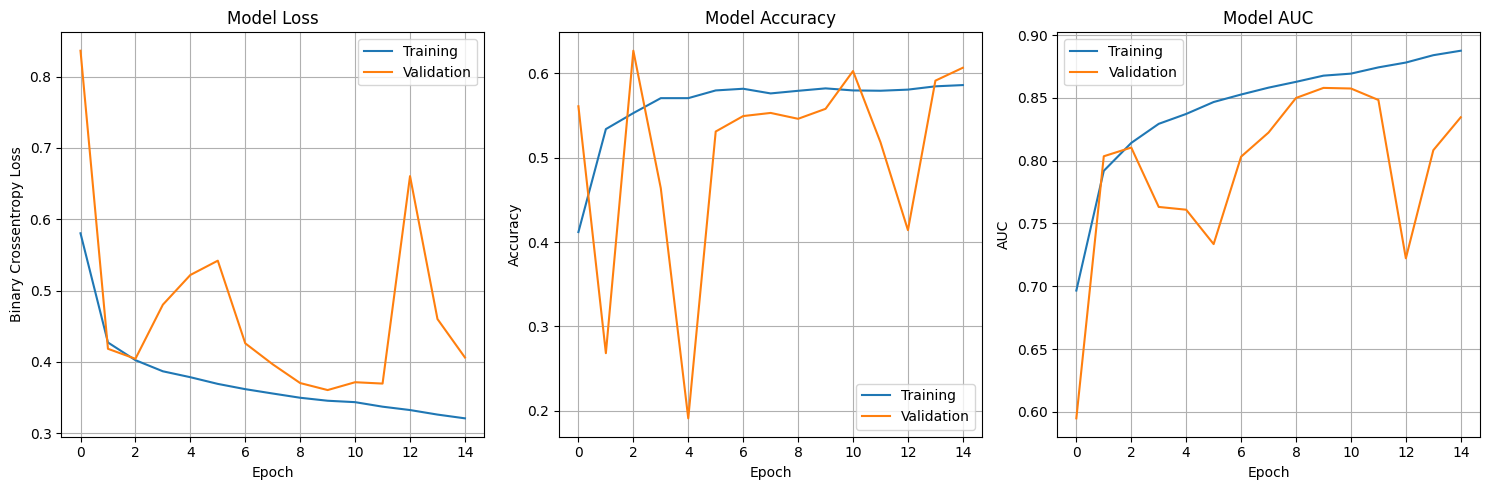


Final Training Metrics:
Loss: 0.3210
Accuracy: 0.5862
AUC: 0.8876

Final Validation Metrics:
Loss: 0.4063
Accuracy: 0.6068
AUC: 0.8346


In [17]:
# Multi-label classification setup
# Number of sound categories
num_classes = 8  

# Create and compile model
model = m.cnn_model(input_shape=(128, 128, 1), num_classes=num_classes)
model.summary()

# Train model with added metrics
history = m.train_model(
    model=model,
    train_data=train,
    validation_data=validation,
    epochs=50
)

# Plot training metrics
plt.figure(figsize=(15, 5))

# Loss plot
plt.subplot(1, 3, 1)
plt.plot(history.history['loss'], label='Training')
plt.plot(history.history['val_loss'], label='Validation')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Binary Crossentropy Loss')
plt.legend()
plt.grid(True)

# Accuracy plot
plt.subplot(1, 3, 2)
plt.plot(history.history['accuracy'], label='Training')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# AUC plot
plt.subplot(1, 3, 3)
plt.plot(history.history['auc'], label='Training')
plt.plot(history.history['val_auc'], label='Validation')
plt.title('Model AUC')
plt.xlabel('Epoch')
plt.ylabel('AUC')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# Print final metrics
print("\nFinal Training Metrics:")
print(f"Loss: {history.history['loss'][-1]:.4f}")
print(f"Accuracy: {history.history['accuracy'][-1]:.4f}")
print(f"AUC: {history.history['auc'][-1]:.4f}")

print("\nFinal Validation Metrics:")
print(f"Loss: {history.history['val_loss'][-1]:.4f}")
print(f"Accuracy: {history.history['val_accuracy'][-1]:.4f}")
print(f"AUC: {history.history['val_auc'][-1]:.4f}")

#### Observations on first training attempt
###### The accuracy around 60% suggests room for improvement, but it's not bad for a multi-label audio classification task. The high AUC (>0.83) indicates good discriminative ability.

- Overfitting Signs
    - Training loss (0.3210) is lower than validation loss (0.4063)
    - Training AUC (0.8876) is higher than validation AUC (0.8346)
    - Gaps indicate mild overfitting

- Epochs
    - 50 epochs might be too many given the overfitting
    - Implementing early stopping might help with the overfitting

- Improving the model
    - Data Augmentation for Audio (time shifting, time stretching and noise implementation)
    - Regulate cnn model

# Model Training 2
#### Training Model with Data Augmentation for Comparison

In [ ]:
num_classes = 8
batch_size = 16  # Reduced batch size
epochs = 5      # Reduced epochs

# create/compile model with the same architecture
model_v2 = m.cnn_model(input_shape=(128, 128, 1), num_classes=num_classes)

# early stopping and learning rate reduction
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.2,
        patience=2,
        min_lr=1e-6,
        verbose=1
    )
]

# steps_per_epoch
steps_per_epoch = len(train_files) // batch_size
validation_steps = len(val_files) // batch_size

# train model with optimized parameters
history_v2 = model_v2.fit(
    train,
    validation_data=validation,
    epochs=epochs,
    steps_per_epoch=steps_per_epoch,
    callbacks=callbacks,
    verbose=1
)

# comparison of both training runs
plt.figure(figsize=(15, 5))

# loss comparison
plt.subplot(1, 3, 1)
plt.plot(history.history['loss'], label='Original Training')
plt.plot(history.history['val_loss'], label='Original Validation')
plt.plot(history_v2.history['loss'], label='Optimized Training')
plt.plot(history_v2.history['val_loss'], label='Optimized Validation')
plt.title('Model Loss Comparison')
plt.xlabel('Epoch')
plt.ylabel('Binary Crossentropy Loss')
plt.legend()
plt.grid(True)

# accuracy comparison
plt.subplot(1, 3, 2)
plt.plot(history.history['accuracy'], label='Original Training')
plt.plot(history.history['val_accuracy'], label='Original Validation')
plt.plot(history_v2.history['accuracy'], label='Optimized Training')
plt.plot(history_v2.history['val_accuracy'], label='Optimized Validation')
plt.title('Model Accuracy Comparison')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# AUC comparison
plt.subplot(1, 3, 3)
plt.plot(history.history['auc'], label='Original Training')
plt.plot(history.history['val_auc'], label='Original Validation')
plt.plot(history_v2.history['auc'], label='Optimized Training')
plt.plot(history_v2.history['val_auc'], label='Optimized Validation')
plt.title('Model AUC Comparison')
plt.xlabel('Epoch')
plt.ylabel('AUC')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# comparison metrics
print("\nOriginal Model Metrics:")
print(f"Loss: {history.history['val_loss'][-1]:.4f}")
print(f"Accuracy: {history.history['val_accuracy'][-1]:.4f}")
print(f"AUC: {history.history['val_auc'][-1]:.4f}")

print("\nOptimized Model Metrics:")
print(f"Loss: {history_v2.history['val_loss'][-1]:.4f}")
print(f"Accuracy: {history_v2.history['val_accuracy'][-1]:.4f}")
print(f"AUC: {history_v2.history['val_auc'][-1]:.4f}")

# calculating improvements
loss_improvement = ((history.history['val_loss'][-1] - history_v2.history['val_loss'][-1]) / 
                   history.history['val_loss'][-1] * 100)
acc_improvement = ((history_v2.history['val_accuracy'][-1] - history.history['val_accuracy'][-1]) / 
                  history.history['val_accuracy'][-1] * 100)
auc_improvement = ((history_v2.history['val_auc'][-1] - history.history['val_auc'][-1]) / 
                  history.history['val_auc'][-1] * 100)

print("\nImprovements:")
print(f"Loss: {loss_improvement:.1f}%")
print(f"Accuracy: {acc_improvement:.1f}%")
print(f"AUC: {auc_improvement:.1f}%")

Epoch 1/5


2025-04-25 22:36:39.650903: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.
2025-04-25 22:36:50.613036: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:452] ShuffleDatasetV3:16: Filling up shuffle buffer (this may take a while): 330 of 1000
2025-04-25 22:37:08.625853: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:482] Shuffle buffer filled.


424/846 ━━━━━━━━━━━━━━━━━━━━ 5:40 808ms/step - accuracy: 0.2762 - auc: 0.6158 - loss: 0.7374

2025-04-25 22:42:53.840928: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]
2025-04-25 22:42:53.840964: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 15327196113287661600
2025-04-25 22:42:53.840972: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 2790295039953617167
2025-04-25 22:42:53.840978: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 17542746804072923669
2025-04-25 22:42:53.840984: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 7564952131842706310
2025-04-25 22:42:53.840990: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 3097234018439234463
2025-04-25 22:42:53.840994: I tensorflow/core/framework/local_rendezv